<a href="https://colab.research.google.com/github/juancarlosch1708-spec/IA/blob/main/RNN/bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

_df = pd.read_csv("/content/Bitcoin_1_1_2024-6_9_2024_historical_data_coinmarketcap.csv", delimiter=';')
# Ordenamos correctamente
_df = _df.sort_index(ascending=False)
_df.head()

,timeOpen,timeClose,timeHigh,timeLow,name,open,high,low,close,volume,marketCap,timestamp
158,2024-01-03T00:00:00.000Z,2024-01-03T23:59:59.999Z,2024-01-03T09:40:00.000Z,2024-01-03T12:10:00.000Z,2781,44961.603187,45503.241795,40813.534868,42848.175641,4.634232e+10,8.393459e+11,2024-01-03T23:59:59.999Z
157,2024-01-04T00:00:00.000Z,2024-01-04T23:59:59.999Z,2024-01-04T22:22:00.000Z,2024-01-04T01:26:00.000Z,2781,42855.814761,44770.023414,42675.174007,44179.921701,3.044809e+10,8.654825e+11,2024-01-04T23:59:59.999Z
156,2024-01-05T00:00:00.000Z,2024-01-05T23:59:59.999Z,2024-01-05T23:07:00.000Z,2024-01-05T01:49:00.000Z,2781,44192.978699,44353.285859,42784.718266,44162.691630,3.233603e+10,8.651827e+11,2024-01-05T23:59:59.999Z
155,2024-01-06T00:00:00.000Z,2024-01-06T23:59:59.999Z,2024-01-06T00:10:00.000Z,2024-01-06T07:07:00.000Z,2781,44178.954607,44227.631307,43475.156431,43989.194093,1.609250e+10,8.618220e+11,2024-01-06T23:59:59.999Z
154,2024-01-07T00:00:00.000Z,2024-01-07T23:59:59.999Z,2024-01-07T14:09:00.000Z,2024-01-07T23:45:00.000Z,2781,43998.464243,44495.571471,43662.228627,43943.097229,1.933057e+10,8.609518e+11,2024-01-07T23:59:59.999Z


Carga el CSV usando ; como separador.

Ordena las filas al revés (de la última a la primera).

Muestra las primeras filas para revisar que se cargó bien.

In [ ]:
'timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
'low', 'close', 'volume', 'marketCap', 'timestamp'

('low', 'close', 'volume', 'marketCap', 'timestamp')

imeOpen → Hora de apertura.

timeClose → Hora de cierre.

timeHigh → Hora del precio más alto.

timeLow → Hora del precio más bajo.

name → Nombre del activo.

open → Precio al abrir.

high → Precio máximo.

low → Precio mínimo.

close → Precio al cerrar.

volume → Cantidad operada.

marketCap → Valor total en el mercado.

timestamp → Fecha del registro.

In [ ]:
df = _df[['timeOpen', 'open', 'high', 'low', 'close']]

La hora (timeOpen)

Precio de apertura (open)

Precio máximo (high)

Precio mínimo (low)

Precio de cierre (close)

In [ ]:
dates = df[['close']].values

Extrae solo la columna close del DataFrame y la convierte a un arreglo (matriz) de Numpy.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dates)

Ajusta los datos para que todos los valores estén entre 0 y 1.
Sirve para que el modelo aprenda mejor.

In [ ]:
window_size = 60


Es la cantidad de días (o datos) que usará el modelo para mirar hacia atrás y predecir el siguiente valor.

In [ ]:
import numpy as np

def create_sequences(data, window_size):
    sequences = []
    labels = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
        # El precio es la primera columna
        labels.append(data[i + window_size, 0])
    return np.array(sequences), np.array(labels)

X, y = create_sequences(scaled_data, window_size)

Ese código crea las secuencias que necesita la red neuronal:

X = grupos de 60 datos seguidos (las ventanas).

y = el dato que sigue después de cada ventana (lo que debe predecir).

In [ ]:
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

Divide los datos:

80% para entrenar → X_train, y_train

20% para probar → X_test, y_test

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, SimpleRNN

model = Sequential()
model.add(SimpleRNN(units=120, return_sequences=True, input_shape=(window_size, X_train.shape[2])))
model.add(SimpleRNN(units=60, return_sequences=False))
model.add(Dense(units=30))
model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dos capas SimpleRNN para aprender patrones en la serie.

Capas Dense para generar la predicción final.

Termina con una salida que predice el siguiente valor.

In [ ]:
from tensorflow.keras.optimizers import Adam

learning_rate = 0.001
adam_optimizer = Adam(learning_rate=learning_rate)

# Compilar el modelo
model.compile(optimizer=adam_optimizer, loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, batch_size=1, epochs=10)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0899
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0280
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0128
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0113
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0056
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0088
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0108
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0117
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0065


Usa Adam como optimizador (qué tan rápido aprende).


Usa MSE como función de error.


Entrena 10 veces (epochs) con lotes de tamaño 1.



In [ ]:
# Hacer predicciones
predictions = model.predict(X_test)

# Desescalar los datos predichos
predictions = scaler.inverse_transform(np.concatenate((predictions, np.zeros((predictions.shape[0], 3))), axis=1))[:,0]
y_test = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((y_test.shape[0], 3))), axis=1))[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


Predice los valores usando el modelo.


Desescala las predicciones y los valores reales para regresarlos a precios reales.


Se agregan ceros solo para que el scaler pueda invertir bien la escala.


Al final se obtiene el precio predicho y el precio real.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 3084.9696422315437
RMSE: 3365.664541506649


MAE: error promedio entre lo real y lo predicho.

RMSE: error total (penaliza errores grandes).

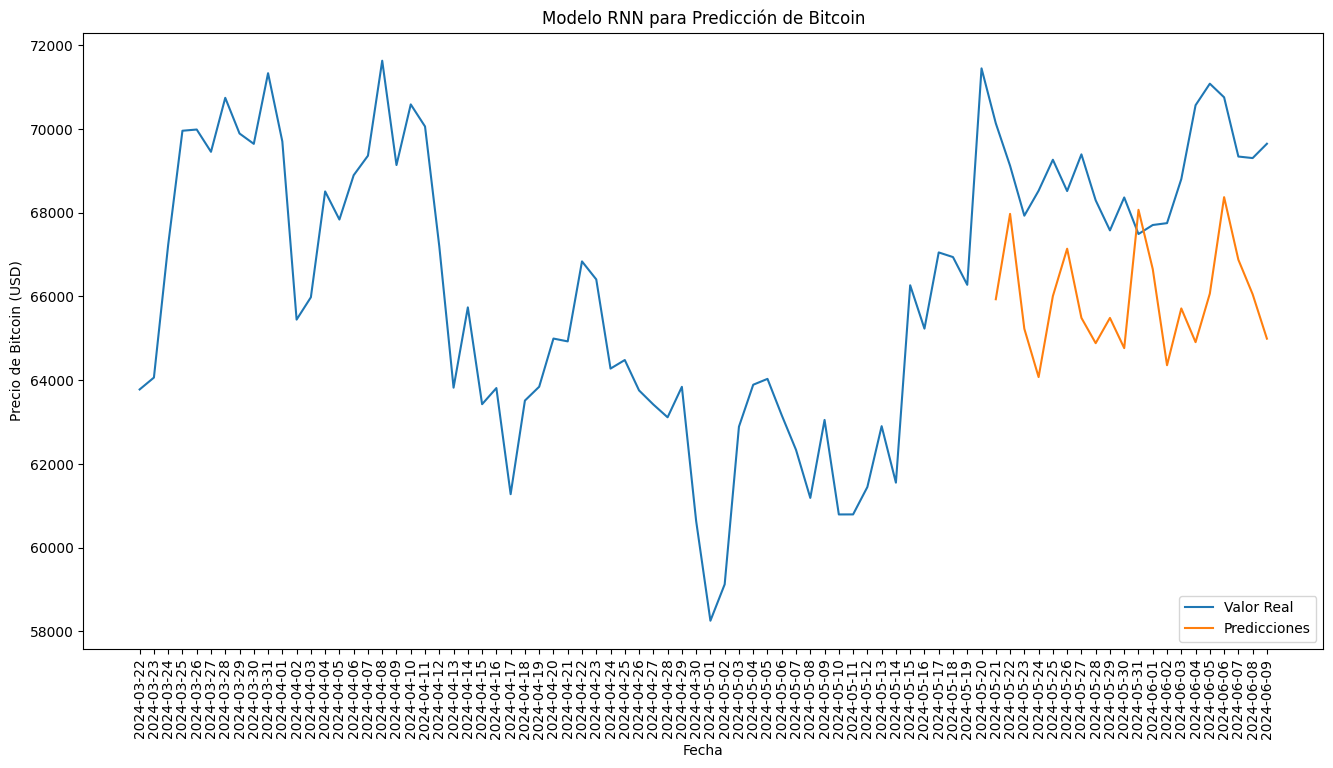

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

valid = df[split:]
# Reiniciar el índice del DataFrame de validación
valid = valid.reset_index(drop=True)
# Inicializar la columna de predicciones con NaN
valid['Predictions'] = np.nan

# Añadir las predicciones al DataFrame de validación desde el punto donde inician las predicciones
valid.loc[window_size:, 'Predictions'] = predictions
dates_valid = pd.to_datetime(valid['timeOpen']).apply(lambda x: x.strftime('%Y-%m-%d')).tolist()

plt.figure(figsize=(16,8))
plt.title('Modelo RNN para Predicción de Bitcoin')
plt.xlabel('Fecha')
plt.ylabel('Precio de Bitcoin (USD)')
plt.plot(dates_valid, valid[['close', 'Predictions']])
plt.legend(['Valor Real', 'Predicciones'], loc='lower right')
plt.xticks(rotation=90)
plt.show()

Prepara un DataFrame con los valores reales y las predicciones.


Pone fechas en el eje X.


Dibuja dos líneas:


Real


Predicción




Sirve para visualizar si tu modelo acierta o se desvía.



In [ ]:
# Generar secuencias para los siguientes días
future_sequences = []
# Última secuencia de los valores que tenemos
last_sequence = X[-1]

days = 10
for _ in range(days):
    # Predecir el siguiente valor
    next_value = model.predict(np.array([last_sequence]))[0, 0]

    # Actualizar la secuencia para la siguiente predicción
    last_sequence = np.concatenate((last_sequence[1:], [[next_value]]), axis=0)

    # Añadir la nueva secuencia a las secuencias futuras
    future_sequences.append(last_sequence)

# Convertir las secuencias futuras a un numpy y reshape para la RNN
future_sequences = np.array(future_sequences)
future_sequences = np.reshape(future_sequences, (future_sequences.shape[0], future_sequences.shape[1], 1))

# Hacer predicciones para los siguientes días
future_predictions = model.predict(future_sequences)

# Desescalar los datos predichos para los siguientes días
future_predictions = scaler.inverse_transform(np.concatenate((future_predictions, np.zeros((future_predictions.shape[0], 3))), axis=1))[:,0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


Toma la última secuencia real que tienes.

Predice el siguiente valor.

Lo mete al final de la secuencia y saca el primero (ventana deslizante).

Repite esto 10 veces para generar predicciones futuras.

Desescala los valores para obtener precios reales.

Resultado: una lista de precios estimados para los próximos 10 días.

In [ ]:
# Última fecha en los datos reales
last_date = df['timeOpen'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=days)[1:]
future_dates = future_dates.strftime('%Y-%m-%d').tolist()

Toma la última fecha real del dataset.


Crea un rango de fechas nuevas (según days).


Convierte esas fechas a texto (YYYY-MM-DD).

Resultado: una lista de fechas para mostrar junto con las predicciones futuras.

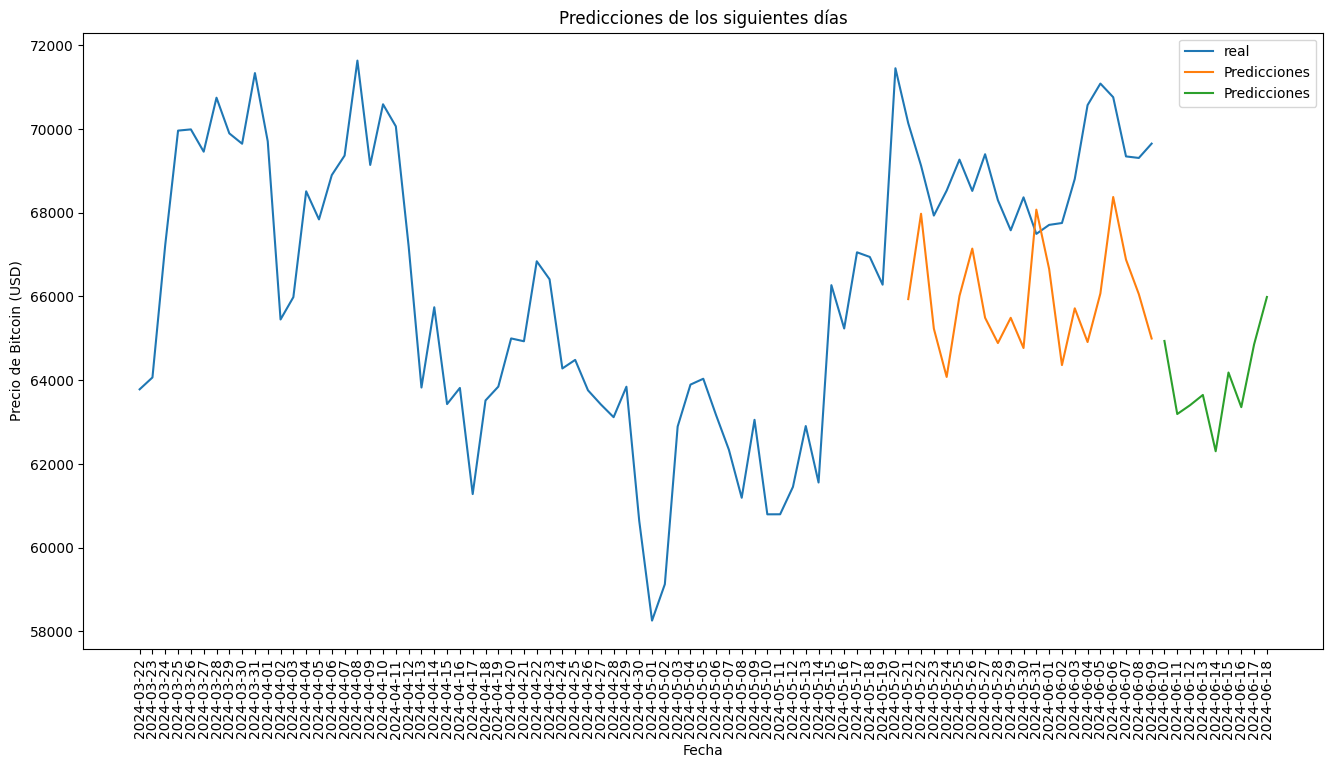

In [ ]:
plt.figure(figsize=(16,8))
plt.title('Predicciones de los siguientes días')
plt.xlabel('Fecha')
plt.ylabel('Precio de Bitcoin (USD)')
plt.plot(dates_valid, valid[['close', 'Predictions']], label=['real', 'Predicciones'])
plt.plot(future_dates, future_predictions[:-1], label='Predicciones')
plt.legend()
plt.xticks(rotation=90)
plt.show()

a serie real (close),

Las predicciones dentro del dataset,

Y las predicciones futuras con sus fechas nuevas.

Muestra en una sola gráfica cómo se comporta el Bitcoin y lo que el modelo predice después.